In [132]:
import datetime
import os
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML
from collections import defaultdict
import yfinance as yf

#Define where the corresponding functions are:
filename_func1 = "Indicators.py"
filename_func3 = "Plot2.py"
    
if os.path.isfile("Updater.py")==True:
    %run Updater.py
    
%run Functions/$filename_func1
%run Functions/$filename_func3

if os.path.isfile("Stock_information.py")==True:
    %run Stock_information.py
else:
    account = ["PTX.DE"]
    c = [{}]
    b = ["ETH-EUR"],[1],[1000]

In [133]:
d_ib, d_h1y, d_cal_EQI, d_qis_EQI, d_top_ETF = get_my_stock_data(account,"2y")

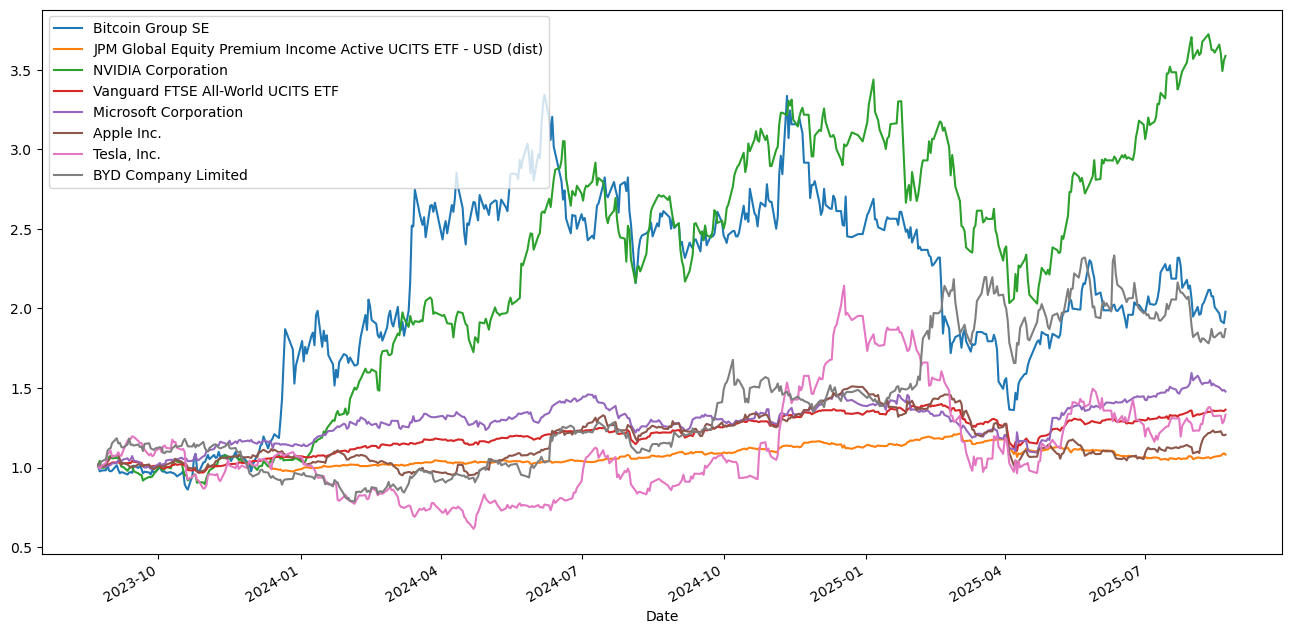

In [134]:
# Cumulative return for stocks from "account" over the last 2 years (10 = 10x the original invest)
plot_my_stock_comparision(account, d_h1y, d_ib)

In [135]:
df_equities, df_etfs, df_other = get_my_stock_variation2(account,d_h1y,d_ib, d_cal_EQI, d_qis_EQI, d_top_ETF)
        
plot_equity_table(df_equities, df_etfs, df_other, width="1200px", height = "800px")

,Ticker,Short Name,Type,Currency,Mean [%],3xStd [%],Last RSI,Sector,Industry,Book Value,KGV,f_KGV,Last Earnings Date,Next Earnings Date,Total Revenue,Rev % Change,Gross Profit,Profit % Change,EBIT,EBIT % Change
0,ADE.DE,Bitcoin Group SE I,EQUITY,EUR/EUR,0.21,12.08,46.93,Financial Services,Asset Management,55.639,113.89,61.19,None,,None,None,None,None,None,None
1,NVD.DE,NVIDIA CORP. R,EQUITY,EUR/USD,0.29,8.77,46.88,Technology,Semiconductors,3.438,57.25,NaN,30.04.2025,27.08.2025,44062 Mio,12.03%,26668 Mio,-7.15%,21973 Mio,-13.07%
2,MSF.F,MICROSOFT CORP. R,EQUITY,EUR/USD,0.09,4.60,23.13,Technology,Software - Infrastructure,46.204,36.77,NaN,30.06.2025,29.10.2025,76441 Mio,9.1%,52427 Mio,8.89%,33231 Mio,3.94%
3,APC.DE,Apple Inc. R,EQUITY,EUR/USD,0.05,4.94,76.70,Technology,Consumer Electronics,4.431,34.35,NaN,30.06.2025,30.10.2025,94036 Mio,-1.39%,43718 Mio,-2.56%,28202 Mio,-4.69%
4,TL0.DE,Tesla Inc. R,EQUITY,EUR/USD,0.12,10.81,65.90,Consumer Cyclical,Auto Manufacturers,23.981,200.38,NaN,30.06.2025,22.10.2025,22496 Mio,16.35%,3878 Mio,22.99%,1635 Mio,140.44%
5,BY6.F,BYD Co. Ltd. R,EQUITY,EUR/CNY,0.16,8.18,52.96,Consumer Cyclical,Auto Manufacturers,24.806,20.50,NaN,31.03.2025,29.08.2025,170360 Mio,-38.02%,34185 Mio,-26.89%,11792 Mio,-37.22%


,Ticker,Short Name,Type,Currency,Mean [%],3xStd [%],Last RSI,Top Holdings
0,JGPI.DE,JPM EII-Gl.Eq.Pr.In.Ac.UCI.ETFR,ETF,EUR/,0.02,1.97,66.68,Southern Co (1.88%)Microsoft Corp (1.77%)Deutsche Telekom AG (1.67%)Johnson & Johnson (1.39%)Roper Technologies Inc (1.32%)Berkshire Hathaway Inc Class B (1.32%)Motorola Solutions Inc (1.31%)McDonald's Corp (1.2%)PepsiCo Inc (1.18%)NTT Inc (1.14%)
1,VGWL.DE,Vanguard FTSE All-World U.ETF R,ETF,EUR/,0.06,2.58,83.71,Microsoft Corp (4.16%)NVIDIA Corp (3.85%)Apple Inc (3.6%)Amazon.com Inc (2.34%)Meta Platforms Inc Class A (1.73%)Broadcom Inc (1.35%)Alphabet Inc Class A (1.22%)Tesla Inc (1.17%)Alphabet Inc Class C (1.03%)Taiwan Semiconductor Manufacturing Co Ltd (0.94%)


In [136]:
multi_plot3(dfi = d_ib,dfh = d_h1y, title="Charts", account = account)

In [137]:
which=2
tick=account[which] 
dfv=yf.Ticker(tick).income_stmt/1000000
quarterly_income_statement = yf.Ticker(tick).quarterly_income_stmt/1000000
        
income_statement_overview(which, d_ib,dfv, quarterly_income_statement)

,2025-04-30,2025-01-31,2024-10-31,2024-07-31,2024-04-30,2024-01-31
Total Revenue,44062.00,39331.00,35082.00,30040.00,26044.00,NaN
Gross Profit,26668.00,28723.00,26156.00,22574.00,20406.00,NaN
EBITDA,22584.00,25821.00,22855.00,19708.00,17753.00,NaN
EBITDA percentage,51.26,65.65,65.15,65.61,68.17,NaN


,NaT,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Total Revenue,148515.00,130497.00,60922.00,26974.00,26914.00
Gross Profit,104121.00,97858.00,44301.00,15356.00,17475.00
EBIT,88903.00,84273.00,34075.00,4443.00,10177.00
EBITDA,90968.00,86137.00,35583.00,5986.00,11351.00
EBITDA percentage,61.25,66.01,58.41,22.19,42.18


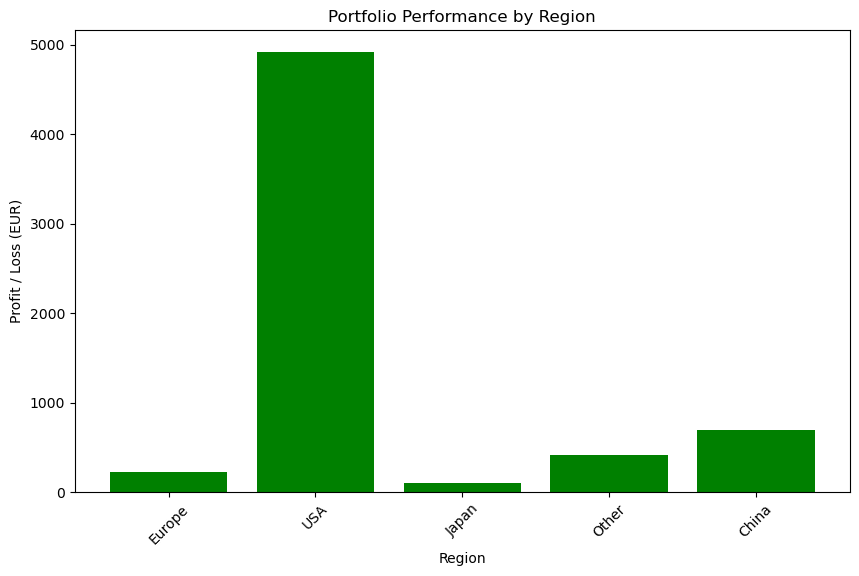

Initial investment:   51191 EUR
Overall gain so far:  6366 EUR / 12.44 % (w/o dividends)
Current investment:   57556 EUR           (w/o dividends)


In [138]:
df_my_portfolio = get_my_portfolio(b[0])

# Create a dictionary from ETF data for easy lookup
etf_data = {etf['ticker']: etf['countries'] for etf in c}

# Prepare the transformed portfolio data
b2 = [{'symbol': b[0][i], 'num_equities': b[1][i], 'purchase_price': b[2][i]} for i in range(len(b[0]))]

# Call function to plot the portfolio
region_labels, region_values = plot_portfolio(df_my_portfolio, b2, etf_data)
print("Initial investment:  ",round(inital_mon), "EUR")
print("Overall gain so far: ",round(sum(region_values)), "EUR /",round(100*sum(region_values)/inital_mon,2),"% (w/o dividends)")
print("Current investment:  ",round(sum(region_values)+inital_mon), "EUR           (w/o dividends)")

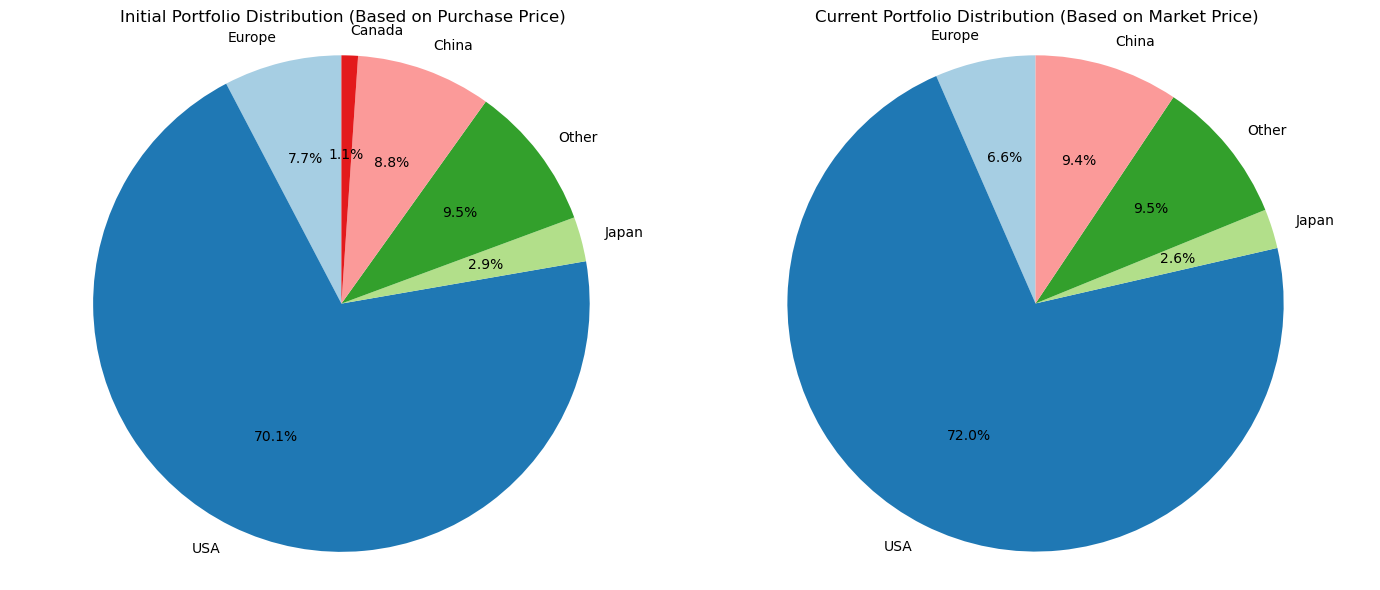

In [139]:
#import matplotlib.pyplot as plt
#from collections import defaultdict

plot_country_distribution(df_my_portfolio, b2, etf_data)

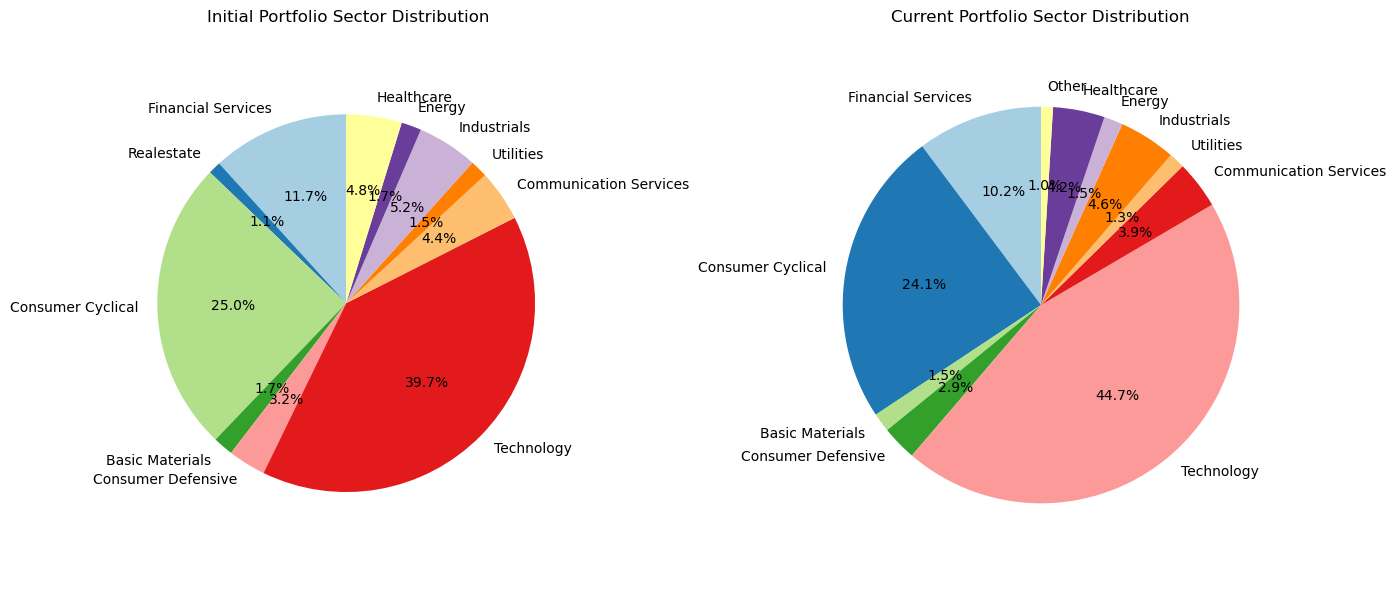

In [140]:
#Idea here is to create a pie chart again, but not with countries, but sectors 
# import yfinance as yf
# import matplotlib.pyplot as plt
# from collections import defaultdict

get_sector_distribution(df_my_portfolio, b2)

In [141]:
# Next ideas: 
# 1    Include dividends into calcualtions 
# 2    Intrinsic value of a copmany. YIelding in when to sell, etc

In [142]:
# Dividends 

# For Aktien: yf.Ticker('BY6.F').info['dividendYield']
# For ETFs:   Addind together all dividends from last year and comparing to current purachse price. Note: Stock price at the dividend date NOT considered

yield_percentages, yield_EUR = calculate_dividends(df_my_portfolio, b2, etf_data)

print("Expected dividend income this year: ",round(sum(np.array(yield_EUR)*np.array(b[1]))), "EUR")

Expected dividend income this year:  229 EUR


In [143]:
df_my_portfolio[11]['sector'] #Aktien: 'sector': technology, 'dividendYield' : 0.84 %,  'trailingEps': 1.07, 'forwardEps': 1.93,
# ETF: yf.Ticker(xy).funds_data.sector_weightings, written dividend funtion, 
yf.Ticker("BY6.F").info['currentPrice']/yf.Ticker("BY6.F").info['trailingEps']
yf.Ticker("BYDDY").info['currentPrice']/yf.Ticker("BYDDY").info['forwardEps']

IndexError: list index out of range